In [49]:
import pandas as pd

# Loading data
df = pd.read_csv(r"E:\Telecom Churn Project\EXCEL\telco_clean.csv")

In [50]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount,RevenueCategory,Churn_Probability
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0–1 Year,1,Low,0.705908
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,2–4 Years,3,Medium,0.027090
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0–1 Year,3,Medium,0.358413
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,2–4 Years,3,Medium,0.028595
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0–1 Year,1,High,0.660110


In [51]:
# Summary of dataset structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   SeniorCitizen      7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   PhoneService       7043 non-null   object 
 7   MultipleLines      7043 non-null   object 
 8   InternetService    7043 non-null   object 
 9   OnlineSecurity     7043 non-null   object 
 10  OnlineBackup       7043 non-null   object 
 11  DeviceProtection   7043 non-null   object 
 12  TechSupport        7043 non-null   object 
 13  StreamingTV        7043 non-null   object 
 14  StreamingMovies    7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  PaperlessBilling   7043 

In [52]:
# Count missing values in columns
print(df.isnull().sum())

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
Churn                 0
TenureGroup          11
ServiceCount          0
RevenueCategory       0
Churn_Probability     0
dtype: int64


In [53]:
# Check unique values in categorical columns
for col in df.select_dtypes(include='object'):
    print(f"{col}: {df[col].unique()[:10]}")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']
gender: ['Female' 'Male']
SeniorCitizen: ['No' 'Yes']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']
TenureGroup: ['0–1 Year' '2–4 Years' '1–2 Years' '4–6 Years' nan]
RevenueCategory: ['Low' 'Medium' 'High']


# Data Cleaning

In [54]:
#  Convertibg TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [55]:
#Converting SeniorCitizen: 0/1 to Yes/No
df["SeniorCitizen"] = df["SeniorCitizen"].replace({1: "Yes", 0: "No"})


In [56]:
# Replacing "No internet service" -> "No"
cols_internet = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
df[cols_internet] = df[cols_internet].replace({"No internet service": "No"})

In [57]:
# Replacing "No phone service" -> "No"
df["MultipleLines"] = df["MultipleLines"].replace({"No phone service": "No"})

In [58]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   SeniorCitizen      7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   PhoneService       7043 non-null   object 
 7   MultipleLines      7043 non-null   object 
 8   InternetService    7043 non-null   object 
 9   OnlineSecurity     7043 non-null   object 
 10  OnlineBackup       7043 non-null   object 
 11  DeviceProtection   7043 non-null   object 
 12  TechSupport        7043 non-null   object 
 13  StreamingTV        7043 non-null   object 
 14  StreamingMovies    7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  PaperlessBilling   7043 

In [59]:
print(df.isnull().sum())

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
Churn                 0
TenureGroup          11
ServiceCount          0
RevenueCategory       0
Churn_Probability     0
dtype: int64


In [60]:
# Fix missing TotalCharges
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

# Feature Engineering

In [61]:
# Creating Tenure Groups for better segmentation
def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 Year"
    elif tenure <= 24:
        return "1-2 Years"
    elif tenure <= 48:
        return "2-4 Years"
    elif tenure <= 60:
        return "4-5 Years"
    else:
        return "5+ Years"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

In [62]:
 # Count services subscribed per customer
service_columns = ["PhoneService","MultipleLines","OnlineSecurity","OnlineBackup",
                   "DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

df["ServiceCount"] = df[service_columns].apply(lambda x: x.eq("Yes").sum(), axis=1)

In [63]:
#  Revenue category based on MonthlyCharges
df["RevenueCategory"] = pd.cut(df["MonthlyCharges"],
                               bins=[0, 35, 70, 200],
                               labels=["Low", "Medium", "High"])


In [64]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount,RevenueCategory,Churn_Probability
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year,1,Low,0.705908
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,2-4 Years,3,Medium,0.027090
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year,3,Medium,0.358413
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years,3,Medium,0.028595
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year,1,High,0.660110


In [65]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
TenureGroup          0
ServiceCount         0
RevenueCategory      0
Churn_Probability    0
dtype: int64


# Exploratory Data Analysis

C:\Users\marut\AppData\Local\Temp\ipykernel_10500\3396095312.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


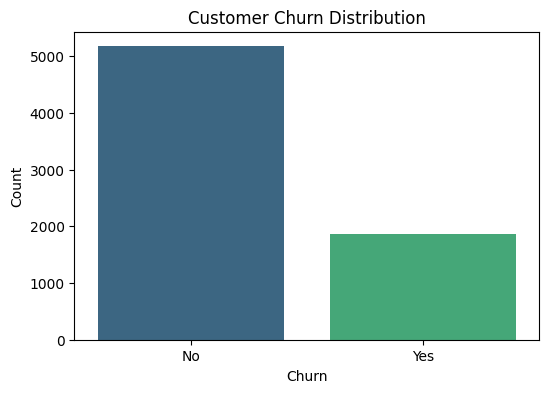

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Calculate churn percentage
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)


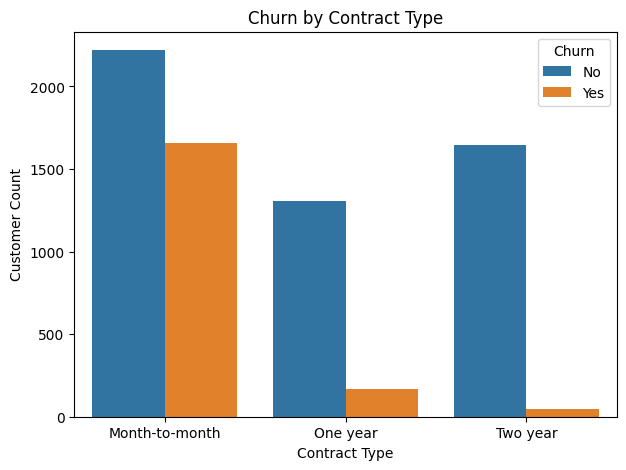

In [67]:
plt.figure(figsize=(7,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.show()


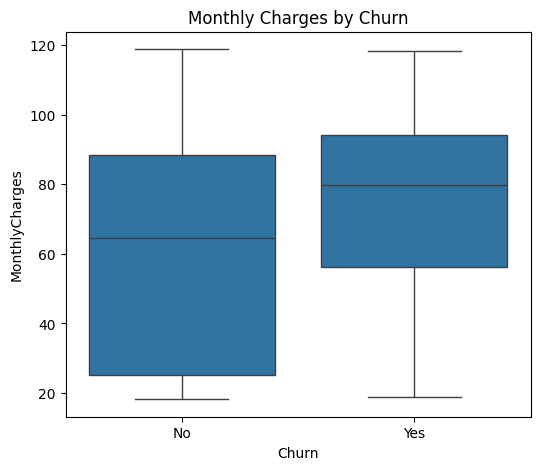

In [68]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()


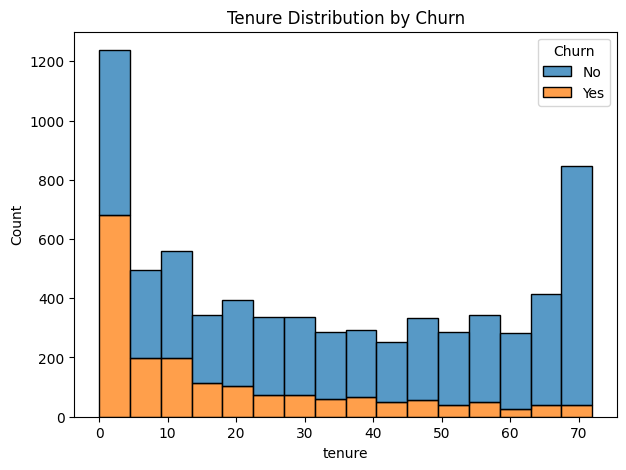

In [69]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.title("Tenure Distribution by Churn")
plt.show()


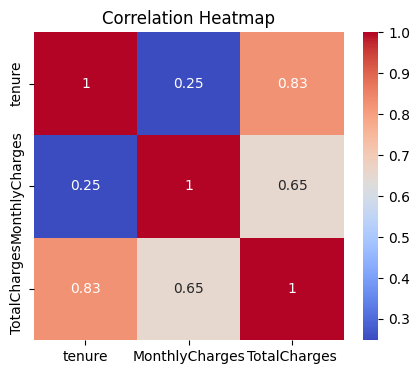

In [70]:


plt.figure(figsize=(5,4))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']]
            .corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


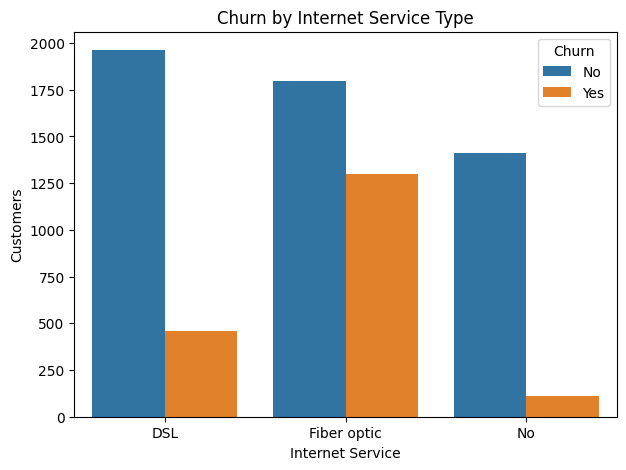

In [71]:
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Customers")
plt.show()


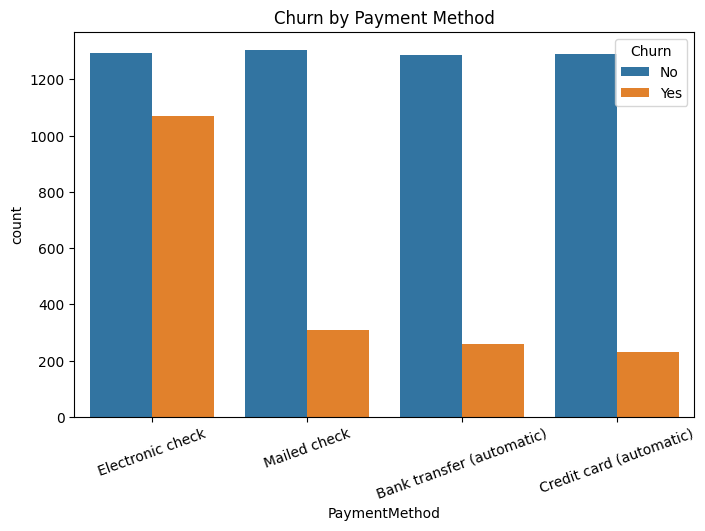

In [72]:
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=20)
plt.show()


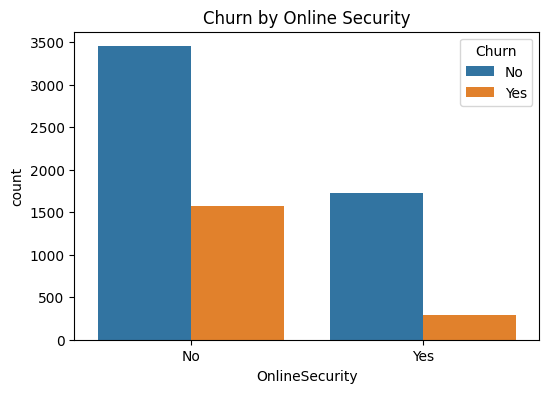

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title("Churn by Online Security")
plt.show()


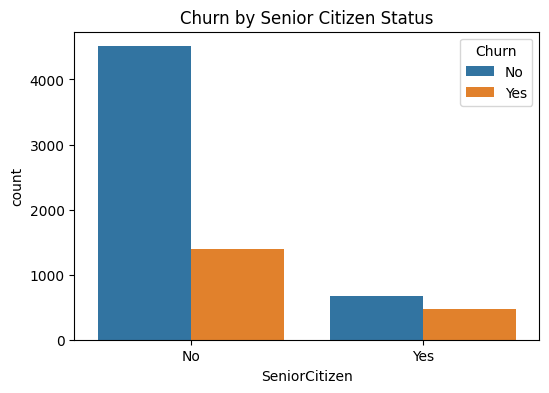

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Churn by Senior Citizen Status")
plt.show()


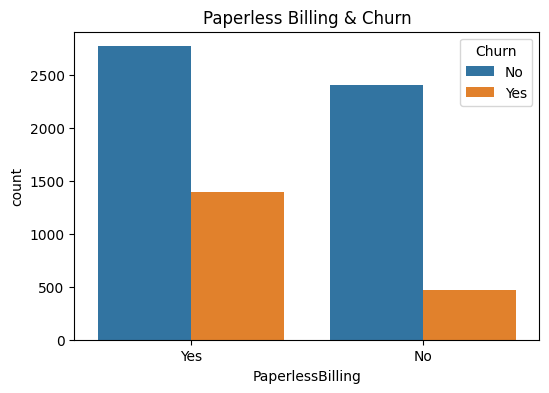

In [75]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaperlessBilling', hue='Churn', data=df)
plt.title("Paperless Billing & Churn")
plt.show()


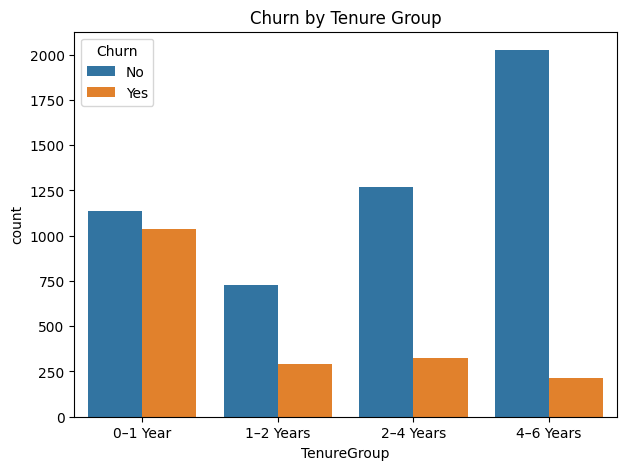

In [76]:
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                           labels=['0–1 Year','1–2 Years','2–4 Years','4–6 Years'])

plt.figure(figsize=(7,5))
sns.countplot(x='TenureGroup', hue='Churn', data=df)
plt.title("Churn by Tenure Group")
plt.show()


In [77]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'ServiceCount', 'RevenueCategory', 'Churn_Probability'],
      dtype='object')

# Feature Engineering

In [78]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes':1, 'No':0})  # convert to numeric

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [79]:
X_train.dtypes


customerID             object
gender                 object
SeniorCitizen          object
Partner                object
Dependents             object
tenure                  int64
PhoneService           object
MultipleLines          object
InternetService        object
OnlineSecurity         object
OnlineBackup           object
DeviceProtection       object
TechSupport            object
StreamingTV            object
StreamingMovies        object
Contract               object
PaperlessBilling       object
PaymentMethod          object
MonthlyCharges        float64
TotalCharges          float64
TenureGroup          category
ServiceCount            int64
RevenueCategory      category
Churn_Probability     float64
dtype: object

In [80]:
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].map({'Yes':1, 'No':0})


In [81]:
X = pd.get_dummies(X, drop_first=True)


In [82]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8069552874378992
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1036
           1       0.66      0.57      0.61       373

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



c:\Users\marut\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7934705464868701
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.53      0.58       373

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [86]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


c:\Users\marut\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:01:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [87]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.7920511000709723
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1036
           1       0.61      0.57      0.59       373

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [88]:

# Create a copy of df before encoding (this is the business dataset for SQL)
df_sql = df.copy()

# Drop unnecessary columns if needed
# df_sql = df_sql.drop(['customerID'], axis=1)  # If not needed for SQL analytics

# Save cleaned dataset
file_path = "telco_clean.csv"
df_sql.to_csv(file_path, index=False)

file_path


'telco_clean.csv'

In [89]:
print(df_sql.columns)
df_sql.head()


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'ServiceCount', 'RevenueCategory', 'Churn_Probability'],
      dtype='object')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount,RevenueCategory,Churn_Probability
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0–1 Year,1,Low,0.705908
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,2–4 Years,3,Medium,0.027090
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0–1 Year,3,Medium,0.358413
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,2–4 Years,3,Medium,0.028595
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0–1 Year,1,High,0.660110


In [90]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'ServiceCount', 'RevenueCategory', 'Churn_Probability'],
      dtype='object')

In [91]:
df.to_csv("telcom final.csv", index=False)


In [92]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': log_model.coef_[0]
})

# Sort by absolute importance
feature_importance['AbsImportance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='AbsImportance', ascending=False)

# Keep top 10 features
feature_importance = feature_importance[['Feature', 'Importance']].head(10)

# Export to CSV
feature_importance.to_csv("feature_importance.csv", index=False)
